In [1]:
import scanpy as sc
import os
import pandas as pd
import matplotlib as mpl
import sys
import numpy as np
import matplotlib.pyplot as plt
sys.path.append('/Users/amossi/Documents/code/')
import FISHspace as sp

%reload_ext autoreload
%autoreload 2

mpl.rcParams['pdf.fonttype'] = 42

# save figure with no pad
mpl.rcParams['savefig.pad_inches'] = 0
mpl.rcParams['savefig.bbox'] = 'tight'

# set axes width
mpl.rcParams['axes.linewidth'] = 0.2
mpl.rcParams['xtick.minor.pad'] = 0
mpl.rcParams['xtick.major.pad'] = 0
mpl.rcParams['ytick.minor.pad'] = 0
mpl.rcParams['ytick.major.pad'] = 0
mpl.rcParams['xtick.minor.width'] = 0.2
mpl.rcParams['xtick.major.width'] = 0.2
mpl.rcParams['ytick.minor.width'] = 0.2
mpl.rcParams['ytick.major.width'] = 0.2

/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.w

# Full Data

In [ ]:
gbo_filepath = '../../data_for_visualization/GBMOrganoids_scVIsurgery20240408.h5ad'
adata_full = sc.read_h5ad(gbo_filepath)

In [3]:
annotation_colors = {
    'rAC':'#FF6EC7',
    'preOPC':'#7befb2',
    '+HYP2': '#C50F53',
    'RG':'#ff9470',
    'GBL':'#b9e670',
    'nIPC':'#FFF192',
    'OPC':'#89c4f4',
    'AC':'#2ecc71',
    '+HYP1':'#EDE8F3',
    '+HYP3':'#840034',
    'FBL':'#9f5afd',
    '+HR1':'#e3ba8f',
    '+HR2':'#825e5c', #'#be5683',
    'OPC2':'#89c4f4',
}

annotation_colors = {
    '+HYP2':'#840034',
    'preOPC': '#7befb2',
    'RG':'#ff9470',
    '+HYP1':'#C50F53',
    'AC1':'#2ecc71',
    'nIPC':'#FFF192',
    'OPC':'#89c4f4',
    'GBL':'#b9e670',
    'hAC':'#EDE8F3',
    'AC2':'#2ecc71',
    'FBL':'#9f5afd',
    'rAC':'#e3ba8f',
    'cOPC':'#038aff',
    'Unknown':'#efeff0',
}

In [9]:
unnecessary_columns =[
    'leiden-bbknn', 'leiden-nn', 'predicted_labels', 'over_clustering', 'majority_voting', 'conf_score', '+HYP0', '+HYP1', '+WH', 'FBL', 'GBL', 'OPC', 'RG', 'Reactive Ast', 
    'nIPC', 'preOPC', 'leiden_1.1', 'leiden_1.2', 'leiden_1.3', 'leiden-bbknn_1.1', 'leiden-bbknn_1.05', 'leiden-bbknn_1.2', 'leiden-bbknn_1.15', 'leiden-bbknn_1.3', 'annotation_20240402',
    ]

In [10]:
for x in unnecessary_columns:
    del adata_full.obs[x]

In [16]:
del adata_full.obs['annotation_unknown']

In [17]:
adata_full.obs['annotation']

aaaocedi-1-0     072h_hyp
aadidjpi-1-0     072h_hyp
aaeaihbj-1-0     072h_hyp
aaggikdb-1-0     072h_hyp
aagiopif-1-0     072h_hyp
                   ...   
oipccffl-1-39        000h
oipkdfcd-1-39        000h
ojanojof-1-39        000h
ojapbbll-1-39        000h
ojbhccni-1-39        000h
Name: annotation, Length: 164271, dtype: category
Categories (10, object): ['000h', '024h_hyp', '024h_hyppla', '024h_pla', ..., '072h_pla', '144h_hyp', '144h_hyppla', '144h_pla']

<Figure size 250x250 with 0 Axes>

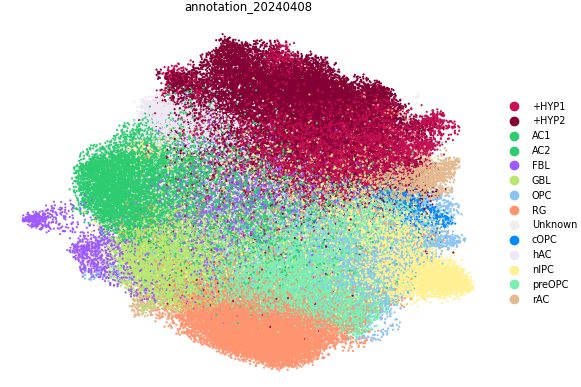

In [19]:
plt.figure(figsize=(2.5,2.5))
sc.pl.umap(
    adata_full,
    color=["annotation_20240408"],
    palette=annotation_colors,
    frameon=False,
    ncols=4,
    s=10,
)

<Figure size 250x250 with 0 Axes>

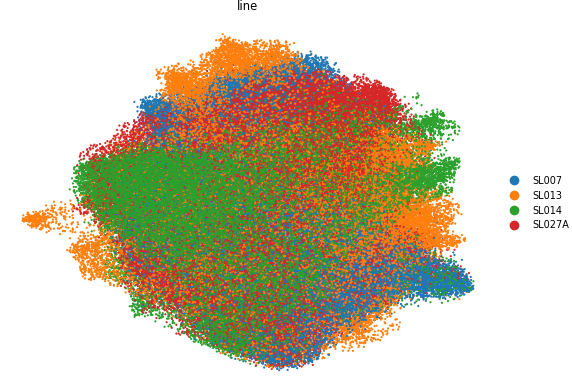

In [21]:
plt.figure(figsize=(2.5,2.5))
sc.pl.umap(
    adata_full,
    color=["line"],
    #palette=annotation_colors,
    frameon=False,
    ncols=4,
    s=10,
)

In [22]:
leiden_colors = adata_full.uns['annotation_20240408_colors']

In [23]:
adata_full = adata_full[adata_full.obs['annotation_20240408'] != 'Unknown']

/var/folders/wt/ft7rv1yx7152d1skc4w_cvbh0000gp/T/ipykernel_35346/3614288102.py:8: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_c.obs['Sample'] = pd.Categorical([l+'-'+t for l, t in  zip(adata_c.obs.line, adata_c.obs.time)])
INFO:root:First filter, 5809 cells left
INFO:root:Zoom filter, 5809 cells left
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:138: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _ = gdf[gdf[cluster_key].isin(grey_clusters)].plot(
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:163: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  im = gdf_.plot(color= palette[c], edgecolor='black',linewidth=linewidth, ax=ax1,rasterized=True,facecolor=facecolor,alpha=alpha)


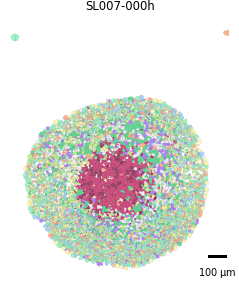

INFO:root:First filter, 6118 cells left
INFO:root:Zoom filter, 6118 cells left
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:138: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _ = gdf[gdf[cluster_key].isin(grey_clusters)].plot(


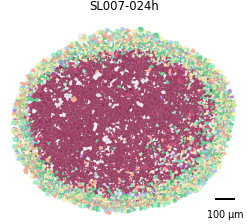

INFO:root:First filter, 7274 cells left
INFO:root:Zoom filter, 7274 cells left
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:138: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _ = gdf[gdf[cluster_key].isin(grey_clusters)].plot(
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:163: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  im = gdf_.plot(color= palette[c], edgecolor='black',linewidth=linewidth, ax=ax1,rasterized=True,facecolor=facecolor,alpha=alpha)


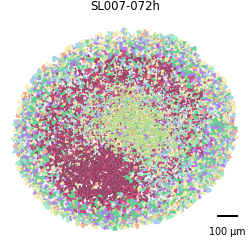

INFO:root:First filter, 4448 cells left
INFO:root:Zoom filter, 4448 cells left
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:138: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _ = gdf[gdf[cluster_key].isin(grey_clusters)].plot(


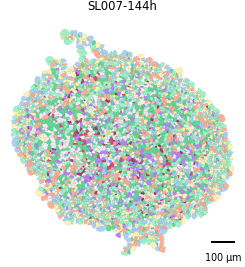

INFO:root:First filter, 3299 cells left
INFO:root:Zoom filter, 3299 cells left
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:138: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _ = gdf[gdf[cluster_key].isin(grey_clusters)].plot(


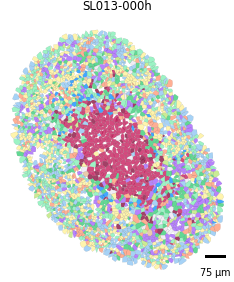

INFO:root:First filter, 4714 cells left
INFO:root:Zoom filter, 4714 cells left
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:138: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _ = gdf[gdf[cluster_key].isin(grey_clusters)].plot(


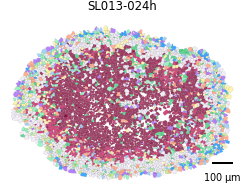

INFO:root:First filter, 3448 cells left
INFO:root:Zoom filter, 3448 cells left
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:138: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _ = gdf[gdf[cluster_key].isin(grey_clusters)].plot(


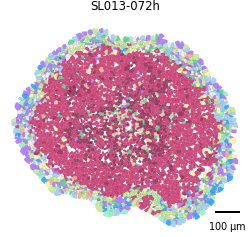

INFO:root:First filter, 3784 cells left
INFO:root:Zoom filter, 3784 cells left
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:138: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _ = gdf[gdf[cluster_key].isin(grey_clusters)].plot(


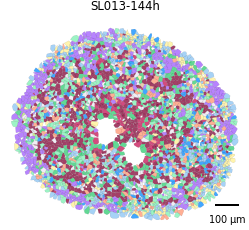

INFO:root:First filter, 2171 cells left
INFO:root:Zoom filter, 2171 cells left
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:138: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _ = gdf[gdf[cluster_key].isin(grey_clusters)].plot(


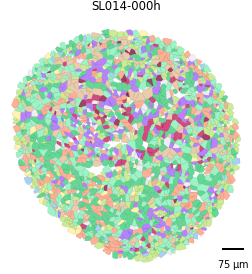

INFO:root:First filter, 2117 cells left
INFO:root:Zoom filter, 2117 cells left
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:138: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _ = gdf[gdf[cluster_key].isin(grey_clusters)].plot(
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:163: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  im = gdf_.plot(color= palette[c], edgecolor='black',linewidth=linewidth, ax=ax1,rasterized=True,facecolor=facecolor,alpha=alpha)


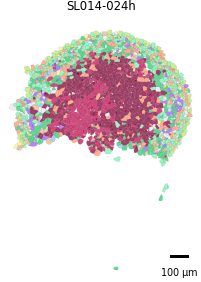

INFO:root:First filter, 2150 cells left
INFO:root:Zoom filter, 2150 cells left
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:138: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _ = gdf[gdf[cluster_key].isin(grey_clusters)].plot(
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:163: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  im = gdf_.plot(color= palette[c], edgecolor='black',linewidth=linewidth, ax=ax1,rasterized=True,facecolor=facecolor,alpha=alpha)


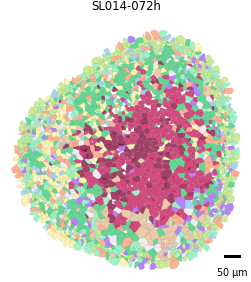

INFO:root:First filter, 2609 cells left
INFO:root:Zoom filter, 2609 cells left
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:138: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _ = gdf[gdf[cluster_key].isin(grey_clusters)].plot(
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:163: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  im = gdf_.plot(color= palette[c], edgecolor='black',linewidth=linewidth, ax=ax1,rasterized=True,facecolor=facecolor,alpha=alpha)


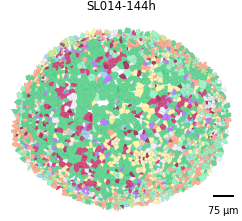

INFO:root:First filter, 4260 cells left
INFO:root:Zoom filter, 4260 cells left
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:138: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _ = gdf[gdf[cluster_key].isin(grey_clusters)].plot(


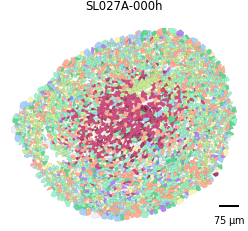

INFO:root:First filter, 5617 cells left
INFO:root:Zoom filter, 5617 cells left
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:138: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _ = gdf[gdf[cluster_key].isin(grey_clusters)].plot(


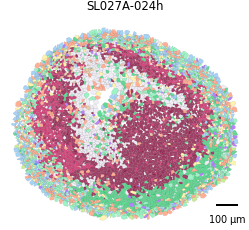

INFO:root:First filter, 2188 cells left
INFO:root:Zoom filter, 2188 cells left
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:138: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _ = gdf[gdf[cluster_key].isin(grey_clusters)].plot(


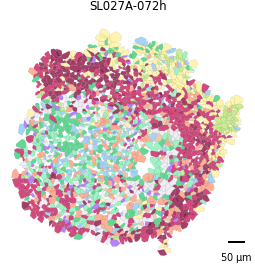

INFO:root:First filter, 4014 cells left
INFO:root:Zoom filter, 4014 cells left
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:138: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _ = gdf[gdf[cluster_key].isin(grey_clusters)].plot(
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:163: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  im = gdf_.plot(color= palette[c], edgecolor='black',linewidth=linewidth, ax=ax1,rasterized=True,facecolor=facecolor,alpha=alpha)


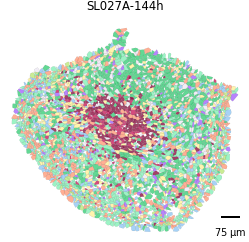

In [25]:
cluster_key = 'annotation_20240408'
folder = 'annotation20240408'
filename = 'Hypoxia'

adata_c = adata_full[(adata_full.obs.condition == 'hyp') | (adata_full.obs.condition == 'initial')]

#add Sample for plotting lines separaterly
adata_c.obs['Sample'] = pd.Categorical([l+'-'+t for l, t in  zip(adata_c.obs.line, adata_c.obs.time)])
adata_c.obs['Area'] = adata_c.obs.cell_area

line_order = adata_c.obs.line.cat.categories.tolist()
time_order = ['000h', '024h', '072h', '144h']


for s in adata_c.obs['Sample'].cat.categories:
    fig, axs= plt.subplots(nrows=1, ncols=1,figsize=(3,3))
    n = line_order.index(s.split('-')[0])
    t = time_order.index(s.split('-')[1])
    
    sp.pl.plot_polygons(
        adata_c,
        sample=s,
        clusters=adata_c.obs[cluster_key].cat.categories.tolist(),
        cluster_key=cluster_key,
        palette= annotation_colors,
        area_min_size=3,
        ax=axs,
    )
    
    axs.title.set_text('{}-{}'.format
                               (
                                   s.split('-')[0], 
                                   s.split('-')[1],
                               )
                              )
    plt.savefig('figures/{}/{}_{}.svg'.format(folder, filename, s), dpi=300, format='svg',bbox_inches='tight')
    plt.show()

/var/folders/wt/ft7rv1yx7152d1skc4w_cvbh0000gp/T/ipykernel_35346/2619214083.py:7: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_c.obs['Sample'] = pd.Categorical([l+'-'+t for l, t in  zip(adata_c.obs.line, adata_c.obs.time)])
INFO:root:First filter, 5809 cells left
INFO:root:Zoom filter, 5809 cells left
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:138: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _ = gdf[gdf[cluster_key].isin(grey_clusters)].plot(
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:163: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  im = gdf_.plot(color= palette[c], edgecolor='black',linewidth=linewidth, ax=ax1,rasterized=True,facecolor=facecolor,alpha=alpha)


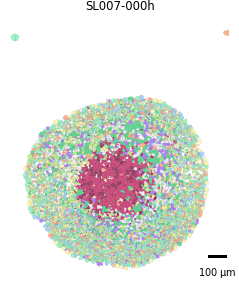

INFO:root:First filter, 3493 cells left
INFO:root:Zoom filter, 3493 cells left
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:138: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _ = gdf[gdf[cluster_key].isin(grey_clusters)].plot(


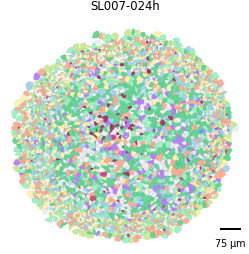

INFO:root:First filter, 5598 cells left
INFO:root:Zoom filter, 5598 cells left
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:138: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _ = gdf[gdf[cluster_key].isin(grey_clusters)].plot(


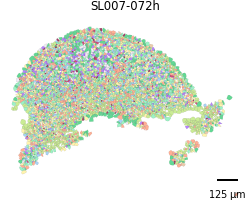

INFO:root:First filter, 7751 cells left
INFO:root:Zoom filter, 7751 cells left
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:138: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _ = gdf[gdf[cluster_key].isin(grey_clusters)].plot(
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:163: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  im = gdf_.plot(color= palette[c], edgecolor='black',linewidth=linewidth, ax=ax1,rasterized=True,facecolor=facecolor,alpha=alpha)


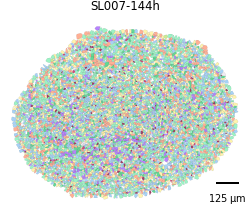

INFO:root:First filter, 3299 cells left
INFO:root:Zoom filter, 3299 cells left
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:138: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _ = gdf[gdf[cluster_key].isin(grey_clusters)].plot(


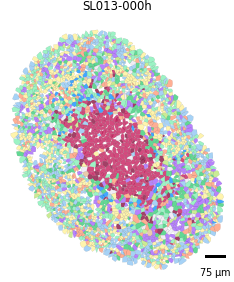

INFO:root:First filter, 4718 cells left
INFO:root:Zoom filter, 4718 cells left
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:138: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _ = gdf[gdf[cluster_key].isin(grey_clusters)].plot(


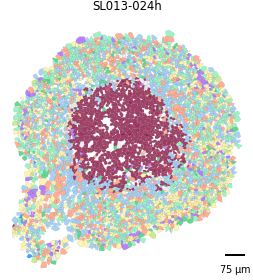

INFO:root:First filter, 2675 cells left
INFO:root:Zoom filter, 2675 cells left
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:138: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _ = gdf[gdf[cluster_key].isin(grey_clusters)].plot(


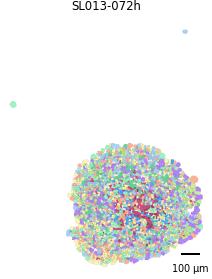

INFO:root:First filter, 1675 cells left
INFO:root:Zoom filter, 1675 cells left
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:138: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _ = gdf[gdf[cluster_key].isin(grey_clusters)].plot(


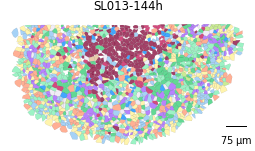

INFO:root:First filter, 2171 cells left
INFO:root:Zoom filter, 2171 cells left
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:138: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _ = gdf[gdf[cluster_key].isin(grey_clusters)].plot(


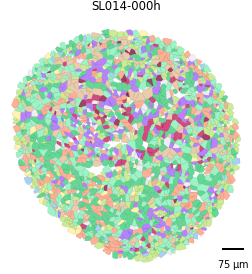

INFO:root:First filter, 3156 cells left
INFO:root:Zoom filter, 3156 cells left
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:138: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _ = gdf[gdf[cluster_key].isin(grey_clusters)].plot(
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:163: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  im = gdf_.plot(color= palette[c], edgecolor='black',linewidth=linewidth, ax=ax1,rasterized=True,facecolor=facecolor,alpha=alpha)


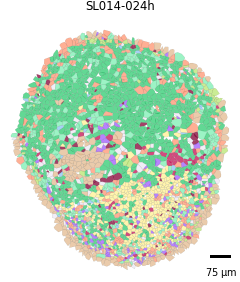

INFO:root:First filter, 2807 cells left
INFO:root:Zoom filter, 2807 cells left
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:138: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _ = gdf[gdf[cluster_key].isin(grey_clusters)].plot(


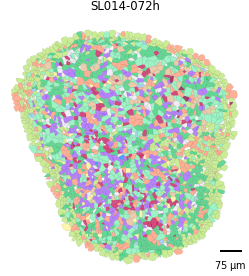

INFO:root:First filter, 2747 cells left
INFO:root:Zoom filter, 2747 cells left
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:138: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _ = gdf[gdf[cluster_key].isin(grey_clusters)].plot(
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:163: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  im = gdf_.plot(color= palette[c], edgecolor='black',linewidth=linewidth, ax=ax1,rasterized=True,facecolor=facecolor,alpha=alpha)


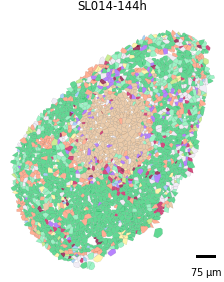

INFO:root:First filter, 4260 cells left
INFO:root:Zoom filter, 4260 cells left
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:138: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _ = gdf[gdf[cluster_key].isin(grey_clusters)].plot(


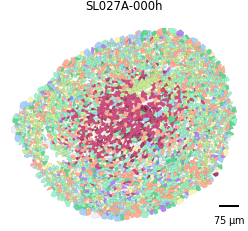

INFO:root:First filter, 5571 cells left
INFO:root:Zoom filter, 5571 cells left
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:138: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _ = gdf[gdf[cluster_key].isin(grey_clusters)].plot(


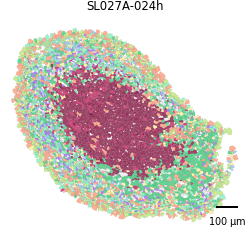

INFO:root:First filter, 5964 cells left
INFO:root:Zoom filter, 5964 cells left
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:138: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _ = gdf[gdf[cluster_key].isin(grey_clusters)].plot(


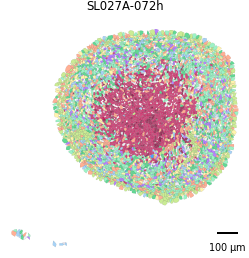

INFO:root:First filter, 6079 cells left
INFO:root:Zoom filter, 6079 cells left
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:138: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _ = gdf[gdf[cluster_key].isin(grey_clusters)].plot(
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:163: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  im = gdf_.plot(color= palette[c], edgecolor='black',linewidth=linewidth, ax=ax1,rasterized=True,facecolor=facecolor,alpha=alpha)


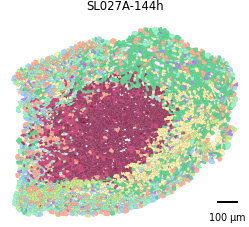

In [26]:
cluster_key = 'annotation_20240408'
folder = 'annotation20240408'
filename = 'Plasma'
adata_c = adata_full[(adata_full.obs.condition == 'pla') | (adata_full.obs.condition == 'initial')]

#add Sample for plotting lines separaterly
adata_c.obs['Sample'] = pd.Categorical([l+'-'+t for l, t in  zip(adata_c.obs.line, adata_c.obs.time)])
adata_c.obs['Area'] = adata_c.obs.cell_area

line_order = adata_c.obs.line.cat.categories.tolist()
time_order = ['000h', '024h', '072h', '144h']


for s in adata_c.obs['Sample'].cat.categories:
    fig, axs= plt.subplots(nrows=1, ncols=1,figsize=(3,3))
    n = line_order.index(s.split('-')[0])
    t = time_order.index(s.split('-')[1])
    
    sp.pl.plot_polygons(
        adata_c,
        sample=s,
        clusters=adata_c.obs[cluster_key].cat.categories.tolist(),
        cluster_key=cluster_key,
        palette= annotation_colors,
        area_min_size=3,
        ax=axs,
    )
    
    axs.title.set_text('{}-{}'.format
                               (
                                   s.split('-')[0], 
                                   s.split('-')[1],
                               )
                              )
    plt.savefig('figures/{}/{}_{}.svg'.format(folder, filename, s), dpi=300, format='svg',bbox_inches='tight')
    plt.show()

/var/folders/wt/ft7rv1yx7152d1skc4w_cvbh0000gp/T/ipykernel_35346/3512005576.py:8: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_c.obs['Sample'] = pd.Categorical([l+'-'+t for l, t in  zip(adata_c.obs.line, adata_c.obs.time)])
INFO:root:First filter, 5809 cells left
INFO:root:Zoom filter, 5809 cells left
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:138: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _ = gdf[gdf[cluster_key].isin(grey_clusters)].plot(
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:163: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  im = gdf_.plot(color= palette[c], edgecolor='black',linewidth=linewidth, ax=ax1,rasterized=True,facecolor=facecolor,alpha=alpha)


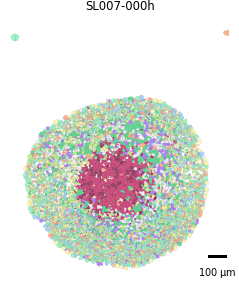

INFO:root:First filter, 4989 cells left
INFO:root:Zoom filter, 4989 cells left
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:138: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _ = gdf[gdf[cluster_key].isin(grey_clusters)].plot(
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:163: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  im = gdf_.plot(color= palette[c], edgecolor='black',linewidth=linewidth, ax=ax1,rasterized=True,facecolor=facecolor,alpha=alpha)


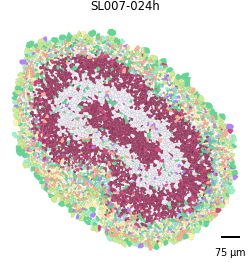

INFO:root:First filter, 7244 cells left
INFO:root:Zoom filter, 7244 cells left
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:138: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _ = gdf[gdf[cluster_key].isin(grey_clusters)].plot(
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:163: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  im = gdf_.plot(color= palette[c], edgecolor='black',linewidth=linewidth, ax=ax1,rasterized=True,facecolor=facecolor,alpha=alpha)


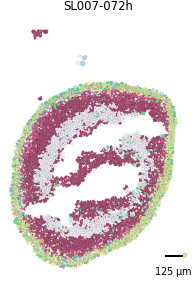

INFO:root:First filter, 4064 cells left
INFO:root:Zoom filter, 4064 cells left
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:138: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _ = gdf[gdf[cluster_key].isin(grey_clusters)].plot(
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:163: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  im = gdf_.plot(color= palette[c], edgecolor='black',linewidth=linewidth, ax=ax1,rasterized=True,facecolor=facecolor,alpha=alpha)


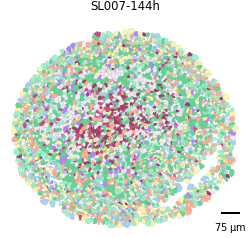

INFO:root:First filter, 3299 cells left
INFO:root:Zoom filter, 3299 cells left
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:138: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _ = gdf[gdf[cluster_key].isin(grey_clusters)].plot(


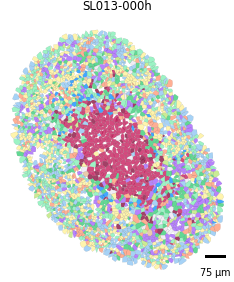

INFO:root:First filter, 3252 cells left
INFO:root:Zoom filter, 3252 cells left
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:138: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _ = gdf[gdf[cluster_key].isin(grey_clusters)].plot(


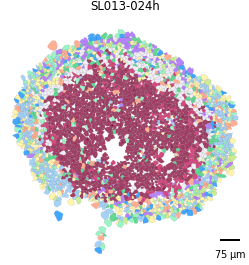

INFO:root:First filter, 1645 cells left
INFO:root:Zoom filter, 1645 cells left
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:138: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _ = gdf[gdf[cluster_key].isin(grey_clusters)].plot(


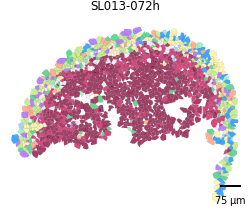

INFO:root:First filter, 2512 cells left
INFO:root:Zoom filter, 2512 cells left
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:138: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _ = gdf[gdf[cluster_key].isin(grey_clusters)].plot(


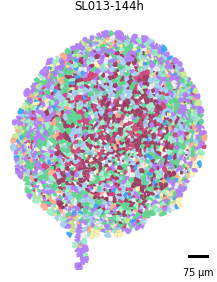

INFO:root:First filter, 2171 cells left
INFO:root:Zoom filter, 2171 cells left
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:138: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _ = gdf[gdf[cluster_key].isin(grey_clusters)].plot(


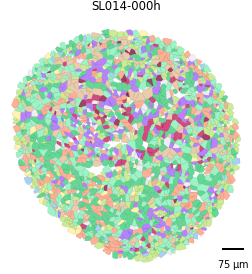

INFO:root:First filter, 3228 cells left
INFO:root:Zoom filter, 3228 cells left
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:138: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _ = gdf[gdf[cluster_key].isin(grey_clusters)].plot(


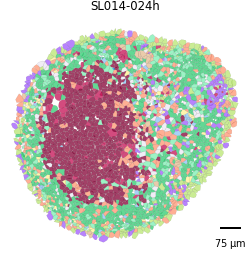

INFO:root:First filter, 3362 cells left
INFO:root:Zoom filter, 3362 cells left
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:138: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _ = gdf[gdf[cluster_key].isin(grey_clusters)].plot(


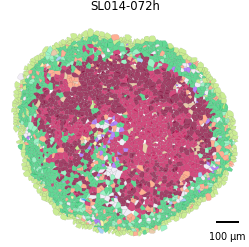

INFO:root:First filter, 3102 cells left
INFO:root:Zoom filter, 3102 cells left
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:138: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _ = gdf[gdf[cluster_key].isin(grey_clusters)].plot(


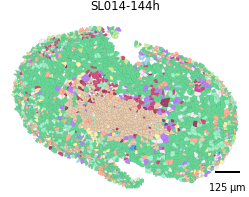

INFO:root:First filter, 4260 cells left
INFO:root:Zoom filter, 4260 cells left
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:138: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _ = gdf[gdf[cluster_key].isin(grey_clusters)].plot(


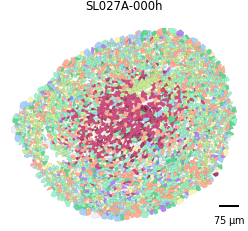

INFO:root:First filter, 3511 cells left
INFO:root:Zoom filter, 3511 cells left
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:138: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _ = gdf[gdf[cluster_key].isin(grey_clusters)].plot(


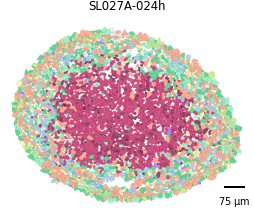

INFO:root:First filter, 5405 cells left
INFO:root:Zoom filter, 5405 cells left
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:138: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _ = gdf[gdf[cluster_key].isin(grey_clusters)].plot(
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:163: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  im = gdf_.plot(color= palette[c], edgecolor='black',linewidth=linewidth, ax=ax1,rasterized=True,facecolor=facecolor,alpha=alpha)


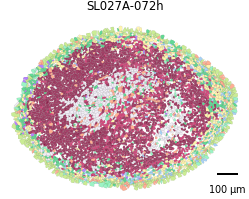

INFO:root:First filter, 5695 cells left
INFO:root:Zoom filter, 5695 cells left
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:138: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _ = gdf[gdf[cluster_key].isin(grey_clusters)].plot(


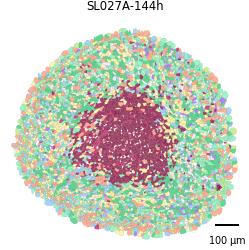

In [ ]:
cluster_key = 'annotation_20240408'
folder = 'annotation20240408'
filename = 'HypoxiaPlasma'

adata_c = adata_full[(adata_full.obs.condition == 'hyppla') | (adata_full.obs.condition == 'initial')]

#add Sample for plotting lines separaterly
adata_c.obs['Sample'] = pd.Categorical([l+'-'+t for l, t in  zip(adata_c.obs.line, adata_c.obs.time)])
adata_c.obs['Area'] = adata_c.obs.cell_area

line_order = adata_c.obs.line.cat.categories.tolist()
time_order = ['000h', '024h', '072h', '144h']


for s in adata_c.obs['Sample'].cat.categories:
    fig, axs= plt.subplots(nrows=1, ncols=1,figsize=(3,3))
    n = line_order.index(s.split('-')[0])
    t = time_order.index(s.split('-')[1])
    
    sp.pl.plot_polygons(
        adata_c,
        sample=s,
        clusters=adata_c.obs[cluster_key].cat.categories.tolist(),
        cluster_key=cluster_key,
        palette= annotation_colors,
        area_min_size=3,
        ax=axs,
    )
    
    axs.title.set_text('{}-{}'.format
                               (
                                   s.split('-')[0], 
                                   s.split('-')[1],
                               )
                              )
    #plt.savefig('figures/{}/{}_{}.svg'.format(folder, filename, s), dpi=300, format='svg',bbox_inches='tight')
    plt.show()